In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../processed_data/cmi_preprocessed.csv")
print(df.head())

   Unnamed: 0  Basic_Demos-Age  Basic_Demos-Sex  CGAS-CGAS_Score  \
0           0              5.0                0             51.0   
1           1              9.0                0             60.5   
2           2             10.0                1             71.0   
3           3              9.0                0             71.0   
4           4             18.0                1             65.0   

   Physical-Height  Physical-Weight  Physical-HeartRate  \
0       116.840000        23.042474           84.333333   
1       121.920000        20.865232           70.000000   
2       143.510000        34.291555           94.000000   
3       142.240000        37.013107           97.000000   
4       137.862733        34.926584           89.000000   

   BIA-BIA_Activity_Level_num  BIA-BIA_BMI  BIA-BIA_DEE  BIA-BIA_FFM  \
0                         2.0      16.8792      1492.00      41.5862   
1                         2.0      14.0371      1498.65      42.0291   
2                   

In [3]:
cols_to_keep = ["Basic_Demos-Age", "CGAS-CGAS_Score", "Physical-Height", "Physical-HeartRate", "BIA-BIA_BMI",
"BIA-BIA_DEE", "BIA-BIA_FFMI", "BIA-BIA_FMI", "Physical-Mean_arterial_pressure", "PAQ_Combined"]
df_outlier_detection = df[cols_to_keep]

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(df_outlier_detection)

In [6]:
from pyod.models.loda import LODA
clf = LODA(contamination=0.01)
clf.fit(X)

,contamination,0.01
,n_bins,10
,n_random_cuts,100


In [7]:
outliers = clf.predict(X)
np.unique(outliers, return_counts=True)

(array([0, 1]), array([8176,   83]))

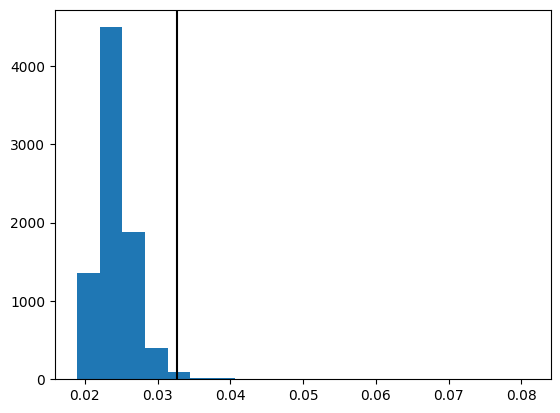

In [8]:
plt.hist(clf.decision_scores_, bins=20)
plt.axvline(np.min(clf.decision_scores_[np.where(outliers==1)]), c='k')
plt.show()

In [9]:
scores = clf.decision_scores_
labels = clf.labels_
df_outlier_detection['anomaly_score'] = scores
df_outlier_detection['is_outlier'] = labels
outliers = df_outlier_detection[df_outlier_detection['is_outlier'] == 1]
print(outliers)
df_outlier_detection.sort_values(by='anomaly_score', ascending=False).head(10)


      Basic_Demos-Age  CGAS-CGAS_Score  Physical-Height  Physical-HeartRate  \
22               12.0        58.000000         153.6700                81.0   
486              17.0        70.000000         176.5300               102.0   
628              12.0        65.000000         165.1000                81.0   
651              20.0        71.000000         199.3900                59.0   
889              17.0        65.000000         179.0700               133.0   
...               ...              ...              ...                 ...   
7935             12.0        50.000000         181.4576                75.5   
7944             15.0        65.500000         168.4274                81.5   
8072             15.0        71.666667         168.3512                83.0   
8191             12.0        60.000000         178.0286                80.0   
8214             10.0        66.500000         155.2702                79.5   

      BIA-BIA_BMI  BIA-BIA_DEE  BIA-BIA_FFMI  BIA-B

,Basic_Demos-Age,CGAS-CGAS_Score,Physical-Height,Physical-HeartRate,BIA-BIA_BMI,BIA-BIA_DEE,BIA-BIA_FFMI,BIA-BIA_FMI,Physical-Mean_arterial_pressure,PAQ_Combined,anomaly_score,is_outlier
5509,13.0,55.5,166.9542,70.5,21.561823,80961.750842,15.292535,4.830934,80.666667,2.500000,0.080935,1
4903,8.0,67.0,184.3786,79.5,22.258700,2454.674282,169.322908,8.938762,95.833333,2.728333,0.064937,1
6143,16.0,49.0,177.3428,87.5,20.548077,124728.000000,17.574909,16.920504,119.666667,2.666667,0.051822,1
6613,12.0,77.5,173.7868,73.5,22.855530,59538.220877,16.836549,8.647894,74.166667,2.000000,0.051072,1
5122,14.0,62.5,159.3342,98.5,20.112471,53363.540487,16.283357,4.891628,77.166667,2.548333,0.048889,1
6362,16.0,61.5,165.6334,66.0,20.808940,52977.596444,18.784844,5.557475,85.055556,2.500000,0.048674,1
8214,10.0,66.5,155.2702,79.5,19.042310,1882.225778,116.086195,12.759265,70.833333,3.000000,0.048197,1
5885,5.0,59.0,143.1036,86.5,19.271938,46031.027969,16.325077,23.272336,80.000000,2.475000,0.045514,1
5188,9.0,56.5,178.9684,80.5,19.165760,1602.107927,118.009584,4.968764,76.833333,2.500000,0.045085,1
7935,12.0,50.0,181.4576,75.5,22.891093,2095.445046,103.294131,6.794361,75.500000,3.000000,0.042971,1


In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# PCA (3 components for both 2D and 3D plots)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

ev = pca.explained_variance_ratio_
print(f"Explained variance — PC1: {ev[0]:.2%}, PC2: {ev[1]:.2%}")
print(f"Cumulative (2 PCs): {ev.sum():.2%}")

Explained variance — PC1: 24.39%, PC2: 6.90%
Cumulative (2 PCs): 31.29%


In [16]:
outlier_mask = labels == 1
n_outliers = outlier_mask.sum()

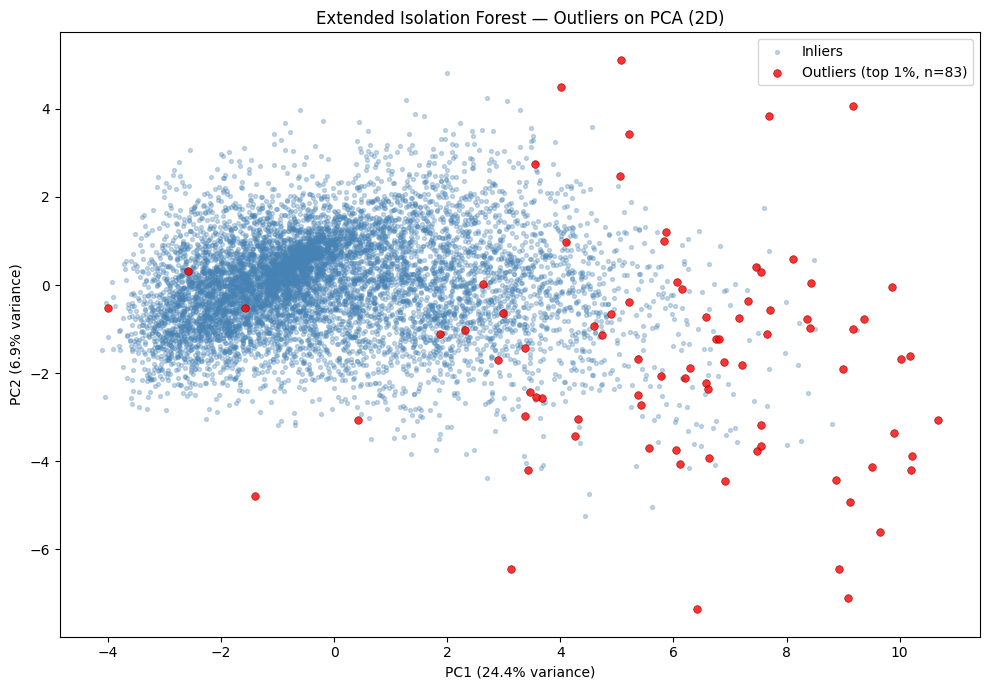

In [17]:
# 2D scatter plot (PC1 vs PC2)
fig, ax = plt.subplots(figsize=(10, 7))

inliers = ~outlier_mask
ax.scatter(X_pca[inliers, 0], X_pca[inliers, 1],
           c="steelblue", s=8, alpha=0.3, label="Inliers")
ax.scatter(X_pca[outlier_mask, 0], X_pca[outlier_mask, 1],
           c="red", s=30, alpha=0.8, edgecolors="darkred", linewidths=0.5,
           label=f"Outliers (top 1%, n={n_outliers})")

ax.set_xlabel(f"PC1 ({ev[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({ev[1]:.1%} variance)")
ax.set_title("Extended Isolation Forest — Outliers on PCA (2D)")
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
df_outlier_detection.to_csv('loda.csv')